# Productivity & Recovery Coach - EDA

Exploratory analysis for the unified master dataset and synthetic longitudinal dataset.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
PROJECT_ROOT = Path('..').resolve()
master = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'master_dataset.csv', parse_dates=['date'])
synthetic = pd.read_csv(PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic_productivity_dataset.csv', parse_dates=['date'])
hourly = pd.read_csv(PROJECT_ROOT / 'data' / 'synthetic' / 'hourly_circadian_profiles.csv', parse_dates=['date'])
master.head()

,user_id,date,chronotype,sleep_need,sleep_hours,sleep_quality,sleep_deficit,sleep_debt,energy_level,mood_score,...,task_complexity,task_load_score,cumulative_load,productivity_score,productivity_trend,burnout_score,burnout_momentum,recovery_score,day_of_week,is_weekend
0,sleep_1,2026-01-01,Intermediate,8.0,6.1,6.0,1.9,1.9,6.0,6.0,...,5.0,100.0,14.5,50.0,0.0,50.0,0.0,50.0,Thursday,0
1,sleep_2,2026-01-01,Intermediate,8.0,6.2,6.0,1.8,1.8,6.0,6.0,...,5.0,100.0,14.5,50.0,0.0,50.0,0.0,50.0,Thursday,0
2,sleep_3,2026-01-01,Intermediate,8.0,6.2,6.0,1.8,1.8,6.0,6.0,...,5.0,100.0,14.5,50.0,0.0,50.0,0.0,50.0,Thursday,0
3,sleep_4,2026-01-01,Intermediate,8.0,5.9,6.0,2.1,2.1,6.0,6.0,...,5.0,100.0,14.5,50.0,0.0,50.0,0.0,50.0,Thursday,0
4,sleep_5,2026-01-01,Intermediate,8.0,5.9,6.0,2.1,2.1,6.0,6.0,...,5.0,100.0,14.5,50.0,0.0,50.0,0.0,50.0,Thursday,0


## Missing Values

In [2]:
missing = pd.DataFrame({
    'missing_count': master.isna().sum(),
    'missing_percent': master.isna().mean() * 100,
})
missing

,missing_count,missing_percent
user_id,0,0.0
date,0,0.0
chronotype,0,0.0
sleep_need,0,0.0
sleep_hours,0,0.0
sleep_quality,0,0.0
sleep_deficit,0,0.0
sleep_debt,0,0.0
energy_level,0,0.0
mood_score,0,0.0


## Distributions

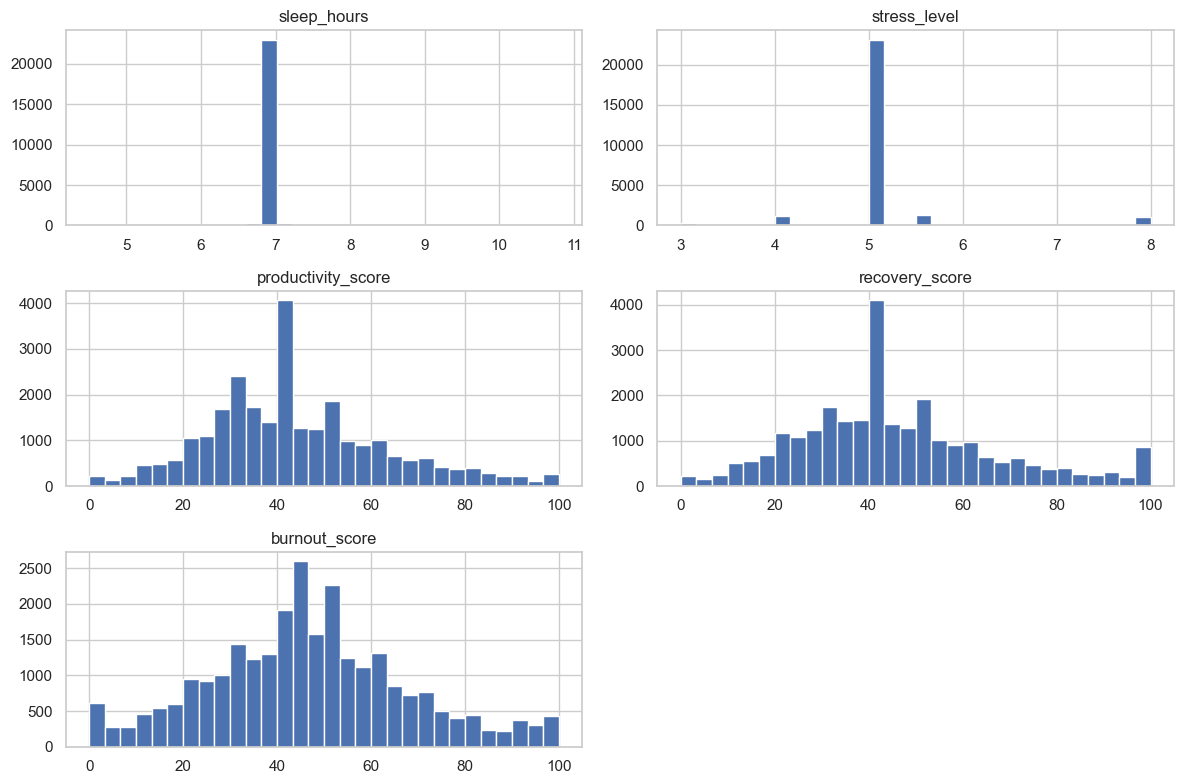

In [3]:
distribution_cols = ['sleep_hours', 'stress_level', 'productivity_score', 'recovery_score', 'burnout_score']
master[distribution_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()

Text(0.5, 1.0, 'Core Feature Boxplots')

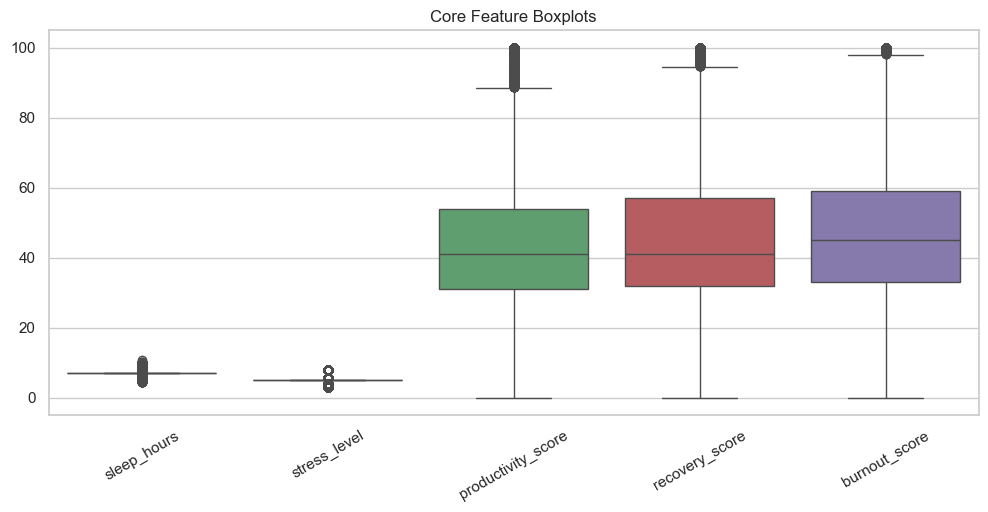

In [4]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=master[distribution_cols])
plt.xticks(rotation=30)
plt.title('Core Feature Boxplots')

## Correlations

Text(0.5, 1.0, 'Correlation Heatmap')

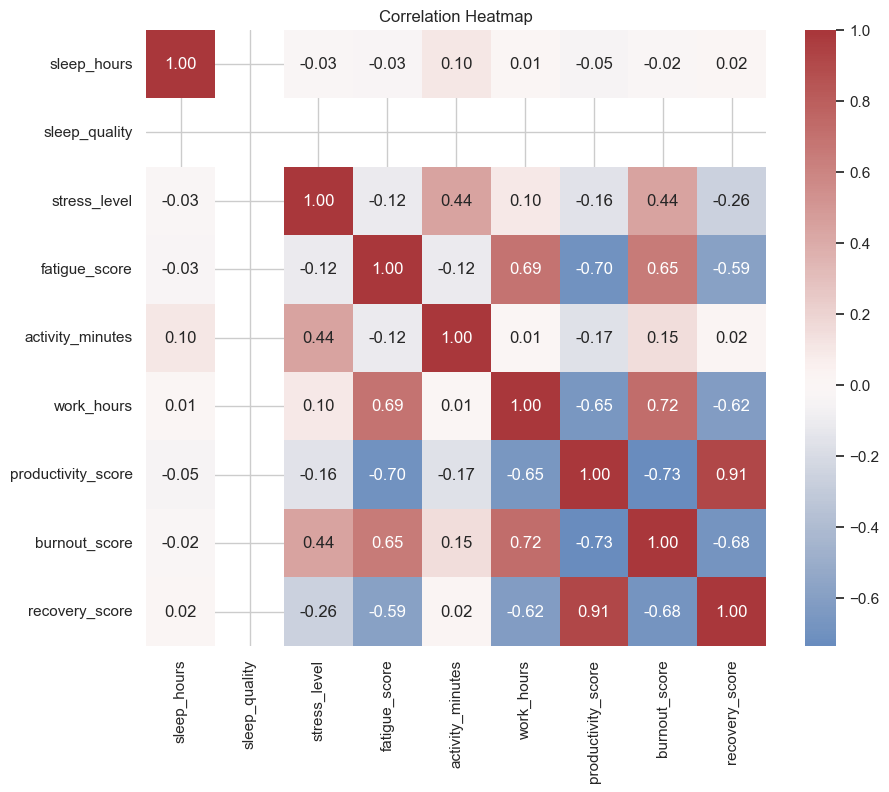

In [5]:
corr_cols = ['sleep_hours', 'sleep_quality', 'stress_level', 'fatigue_score', 'activity_minutes', 'work_hours', 'productivity_score', 'burnout_score', 'recovery_score']
plt.figure(figsize=(10, 8))
sns.heatmap(master[corr_cols].corr(), annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Correlation Heatmap')

## Pairplots And Scatterplots

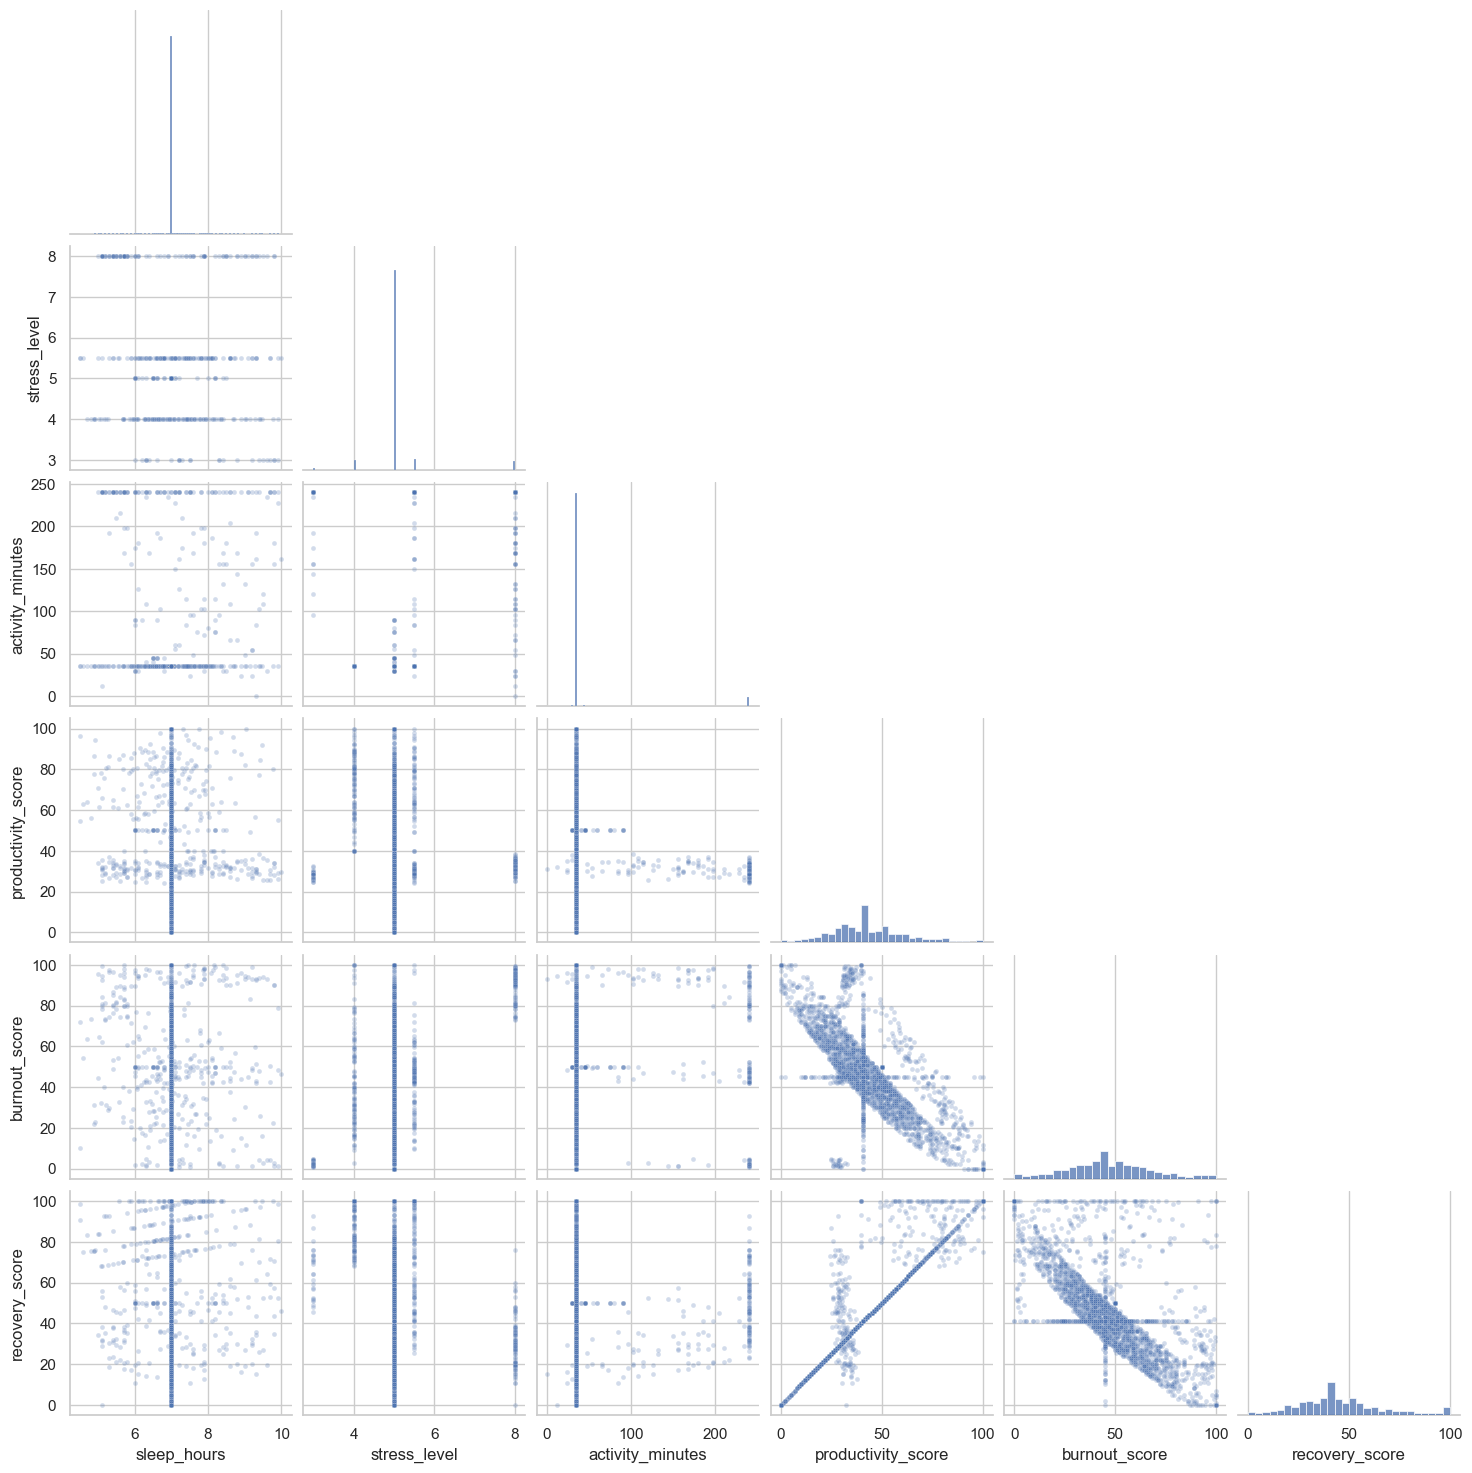

In [6]:
sample = master.sample(min(2500, len(master)), random_state=42)
sns.pairplot(sample[['sleep_hours', 'stress_level', 'activity_minutes', 'productivity_score', 'burnout_score', 'recovery_score']], corner=True, plot_kws={'alpha': 0.25, 's': 12})

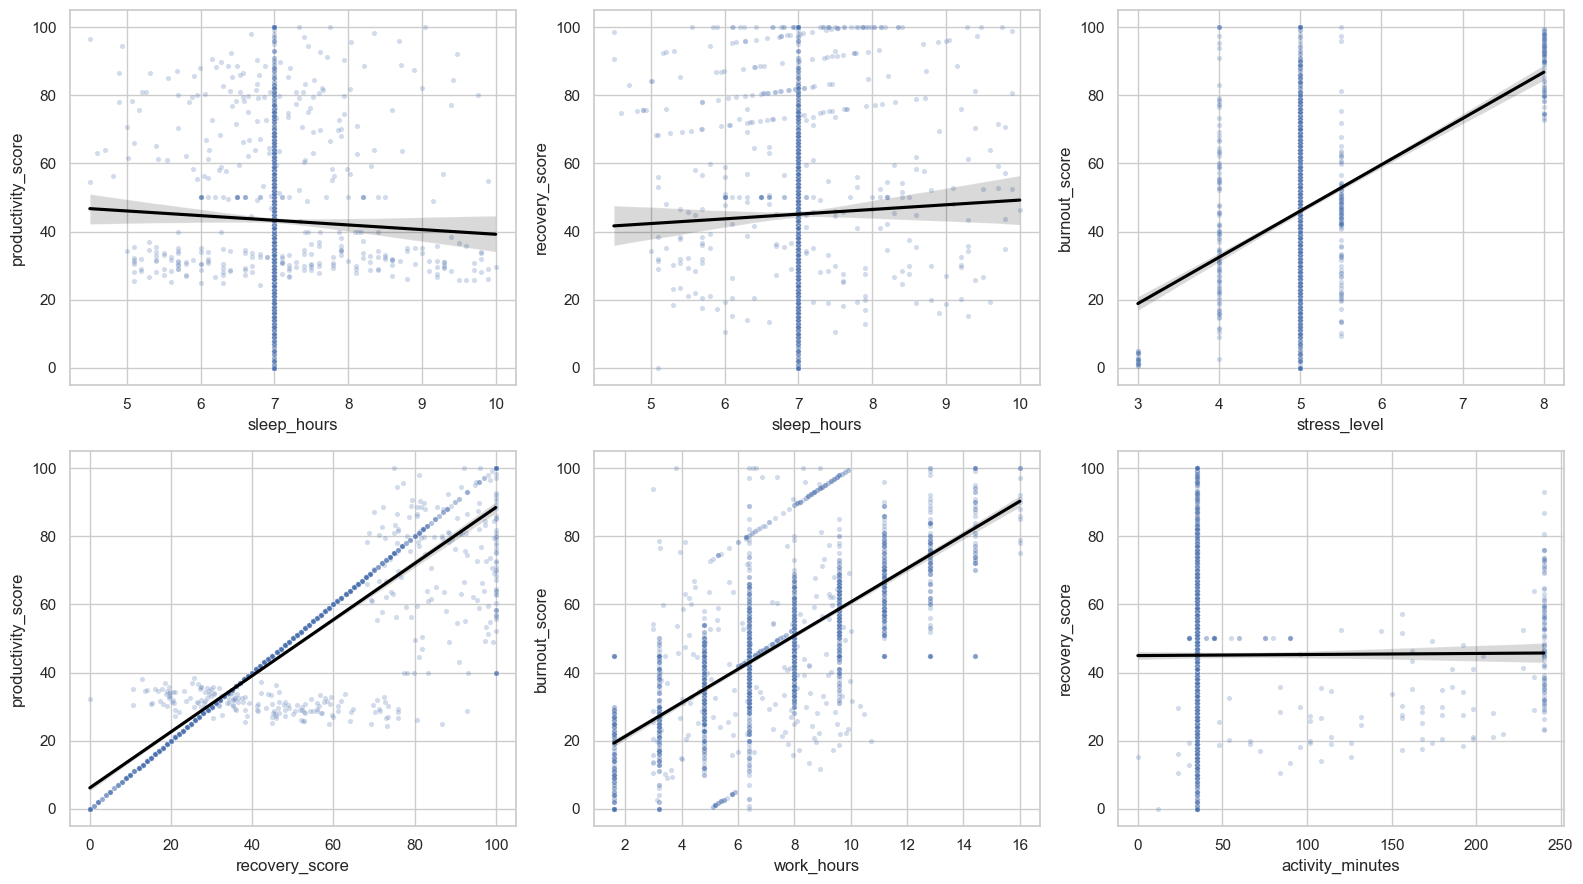

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pairs = [
    ('sleep_hours', 'productivity_score'),
    ('sleep_hours', 'recovery_score'),
    ('stress_level', 'burnout_score'),
    ('recovery_score', 'productivity_score'),
    ('work_hours', 'burnout_score'),
    ('activity_minutes', 'recovery_score'),
]
for ax, (x, y) in zip(axes.ravel(), pairs):
    sns.scatterplot(data=sample, x=x, y=y, alpha=0.25, s=14, ax=ax)
    sns.regplot(data=sample, x=x, y=y, scatter=False, color='black', ax=ax)
plt.tight_layout()

## Sleep Debt And Burnout

Text(0.5, 1.0, 'Sleep Debt vs Burnout')

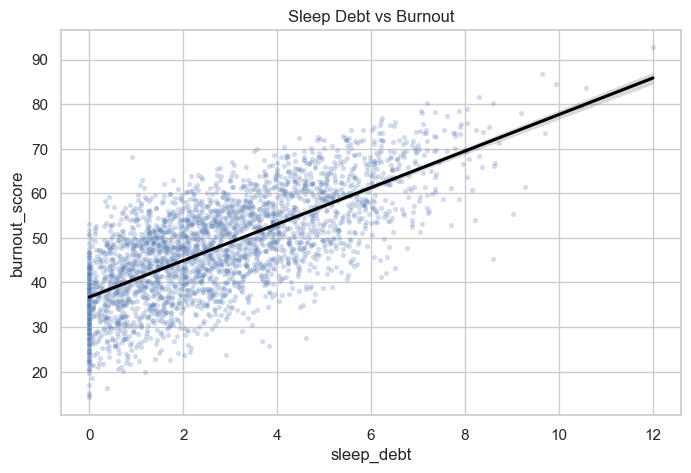

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=synthetic.sample(min(3000, len(synthetic)), random_state=7), x='sleep_debt', y='burnout_score', alpha=0.25, s=14)
sns.regplot(data=synthetic.sample(min(3000, len(synthetic)), random_state=7), x='sleep_debt', y='burnout_score', scatter=False, color='black')
plt.title('Sleep Debt vs Burnout')

## Time-Series Behavior

(array([20454., 20485., 20513., 20544., 20574., 20605., 20635.]),
 [Text(20454.0, 0, '2026-01'),
  Text(20485.0, 0, '2026-02'),
  Text(20513.0, 0, '2026-03'),
  Text(20544.0, 0, '2026-04'),
  Text(20574.0, 0, '2026-05'),
  Text(20605.0, 0, '2026-06'),
  Text(20635.0, 0, '2026-07')])

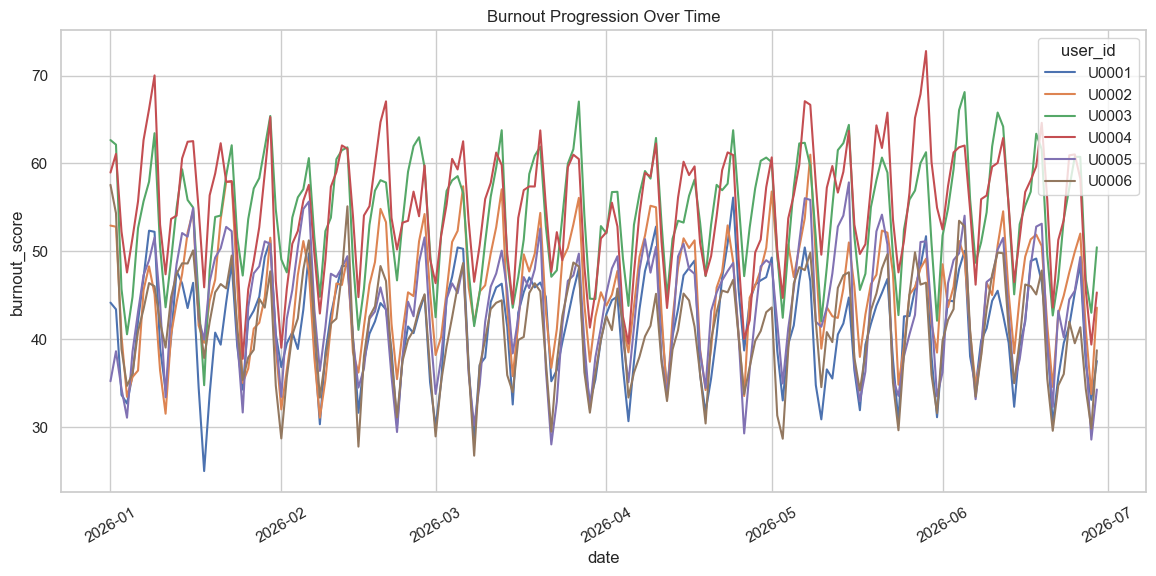

In [9]:
example_users = synthetic['user_id'].drop_duplicates().head(6)
plot_df = synthetic[synthetic['user_id'].isin(example_users)]
plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x='date', y='burnout_score', hue='user_id')
plt.title('Burnout Progression Over Time')
plt.xticks(rotation=30)

([<matplotlib.axis.XTick at 0x1f91a149a90>,
 [Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22')])

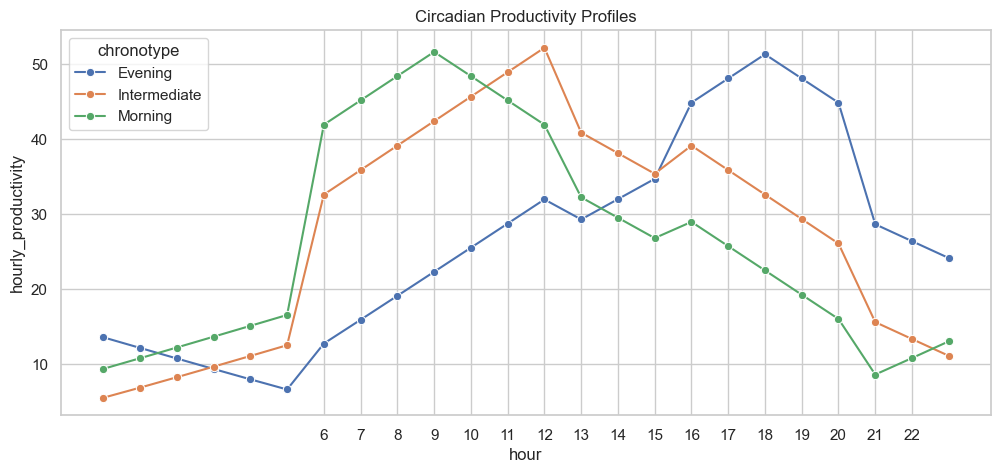

In [10]:
hourly_summary = hourly.groupby(['chronotype', 'hour'], as_index=False)['hourly_productivity'].mean()
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_summary, x='hour', y='hourly_productivity', hue='chronotype', marker='o')
plt.title('Circadian Productivity Profiles')
plt.xticks(range(6, 23))